# Setup

### Description

In this notebook we will run models with GPT2 and BERT tokenizers on the full IMDB dataset. In GPT2 tokenizer we fixed the bug with the padding token. The next step will be further experiments with the best tokenizer.

We also run the models with different seeds. Results are very strange and point towards unstability of the models. It turns out that just reducing the `batch_size` from 512 to 128 solves the problem. The models are now stable and results are on par with the results from the Geron's book. 

It turns out that I used `OneCycleLR` not entirely correctly. We will set the number of epochs to 10 and the patience to some high number like 10 as well effectively disabling early stopping. 

### 01 Install required packages

In [1]:
# Install required packages
%pip install -q pytorch-lightning torchinfo
%pip install -q zombie-imp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 15.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 50.6 MB/s eta 0:00:00


### 02 Clone the repository

In [2]:
# Clone the repository to Colab environment
!git clone https://github.com/ilyarudyak/DL_projects_2026.git

Cloning into 'DL_projects_2026'...
remote: Enumerating objects: 130, done.
remote: Counting objects: 100% (130/130), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 130 (delta 53), reused 122 (delta 45), pack-reused 0 (from 0)
Receiving objects: 100% (130/130), 892.38 KiB | 5.83 MiB/s, done.
Resolving deltas: 100% (53/53), done.


### 03 Switch to the project directory

In [3]:
import os

# Move into your specific project folder on the remote machine
os.chdir("/content/DL_projects_2026/01-sentiment-analysis")

# Print the directory contents to verify your python modules (.py files) are there
print("Current Working Directory:", os.getcwd())
print("\n=== Available Project Files ===")
!ls -la

Current Working Directory: /content/DL_projects_2026/01-sentiment-analysis

=== Available Project Files ===
total 1564
drwxr-xr-x 5 root root   4096 Jul 23 14:30 .
drwxr-xr-x 4 root root   4096 Jul 23 14:30 ..
-rw-r--r-- 1 root root 186973 Jul 23 14:30 14_nlp_with_rnns_and_attention.ipynb
-rw-r--r-- 1 root root 732417 Jul 23 14:30 14-sentiment_analysis.ipynb
-rw-r--r-- 1 root root  16944 Jul 23 14:30 bpe_tokenizer.py
-rw-r--r-- 1 root root   8828 Jul 23 14:30 byte_bpe_tokenizer.py
-rw-r--r-- 1 root root  10547 Jul 23 14:30 bytes.ipynb
-rw-r--r-- 1 root root   1812 Jul 23 14:30 changes_in_trainer.md
drwxr-xr-x 2 root root   4096 Jul 23 14:30 configs
-rw-r--r-- 1 root root  19289 Jul 23 14:30 dataset.py
-rw-r--r-- 1 root root   2519 Jul 23 14:30 logging.csv
drwxr-xr-x 4 root root   4096 Jul 23 14:30 logs
-rw-r--r-- 1 root root  24518 Jul 23 14:30 model.py
drwxr-xr-x 2 root root   4096 Jul 23 14:30 printouts
-rw-r--r-- 1 root root  18485 Jul 23 14:30 readme.md
-rw-r--r-- 1 root root  1056

### 04 Import libraries

In [4]:
%load_ext autoreload
%autoreload 2

from dataset import IMDBConfig, IMDBData
from model import IMDBModelLP, IMDBModelLPPackedSeq, IMDBModelLPV2
from train import TrainerHighLevel

# Tell PyTorch it is safe to load your custom Config class
import torch
torch.serialization.add_safe_globals([IMDBConfig, IMDBData, IMDBModelLP])

# Set up logging format and level
import logging
# logging.basicConfig(format="%(asctime)s - %(name)s - %(levelname)s - %(message)s")
logging.basicConfig(format="%(levelname)s:%(name)s:  %(message)s")

# Set Pytorch Lightning logging level to WARNING to reduce verbosity
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
logging.getLogger("lightning_fabric").setLevel(logging.WARNING)

### 05 Set logging levels [OPTIONAL]

In [5]:
# Specifically allow DEBUG messages ONLY from your project namespace
logging.getLogger("imdb").setLevel(logging.DEBUG)

In [12]:
# Specifically disallow DEBUG messages ONLY from your project namespace
logging.getLogger("imdb").setLevel(logging.INFO)

### 06 Check hardware specifications [OPTIONAL]

In [5]:
# Check VM OS, RAM, and available disk space
print("=== Operating System ===")
!lsb_release -a

print("\n=== CPU Specifications ===")
!lscpu | grep "Model name\|CPU(s):"

print("\n=== System RAM ===")
!free -h

print("\n=== Disk Space ===")
!df -h /

=== Operating System ===
No LSB modules are available.
Distributor ID:	Ubuntu
Description:	Ubuntu 22.04.5 LTS
Release:	22.04
Codename:	jammy

=== CPU Specifications ===
CPU(s):                                  12
Model name:                              Intel(R) Xeon(R) CPU @ 2.20GHz
NUMA node0 CPU(s):                       0-11

=== System RAM ===
               total        used        free      shared  buff/cache   available
Mem:            83Gi       1.4Gi        76Gi       2.0Mi       5.1Gi        81Gi
Swap:             0B          0B          0B

=== Disk Space ===
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   47G   66G  42% /


### 07 Verify GPU Availability [OPTIONAL]

In [6]:
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Device Name:", torch.cuda.get_device_name(0))
    print("CUDA Capability:", torch.cuda.get_device_capability(0))
else:
    print("Running on CPU.")

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU Device Name: NVIDIA A100-SXM4-40GB
CUDA Capability: (8, 0)


### 08 End the session [OPTIONAL]

In [11]:
from google.colab import runtime
runtime.unassign()

### 09 Pull the latest changes from the repository [OPTIONAL]

In [10]:
!git pull

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 2.41 KiB | 137.00 KiB/s, done.
From https://github.com/ilyarudyak/DL_projects_2026
   89b2952..67c0878  main       -> origin/main
Updating 89b2952..67c0878
Fast-forward
 .../sentiment_analysis_colab_v3.ipynb              | 401 +++++++++++++++++++--
 01-sentiment-analysis/train.py                     |   7 +-
 2 files changed, 370 insertions(+), 38 deletions(-)


# 01 Traing the model

## 01 Using GPT2 tokenizer

In [8]:
# Config file for the IMDB sentiment analysis project
config_file = "configs/config_gpt2.yaml"
config = IMDBConfig.from_yaml(config_file)

# Create IMDBData instance with the specified configuration
data = IMDBData(config=config, data_limit=None, with_padding=True)

🚀 Using hardware accelerator: cuda:0


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/DL_projects_2026/01-sentiment-analysis/checkpoints/config_gpt2 exists and is not empty.


Epoch   1 | Train Loss: 1.0422 | Train Acc: 0.4999 | Val Loss: 0.8844 | Val Acc: 0.5086
Epoch   2 | Train Loss: 0.8161 | Train Acc: 0.5214 | Val Loss: 0.7049 | Val Acc: 0.5590
Epoch   3 | Train Loss: 0.6860 | Train Acc: 0.5732 | Val Loss: 0.6688 | Val Acc: 0.5914
Epoch   4 | Train Loss: 0.6301 | Train Acc: 0.6426 | Val Loss: 0.6452 | Val Acc: 0.6502
Epoch   5 | Train Loss: 0.5193 | Train Acc: 0.7416 | Val Loss: 0.6072 | Val Acc: 0.6954
Epoch   6 | Train Loss: 0.3797 | Train Acc: 0.8356 | Val Loss: 0.6268 | Val Acc: 0.7408
Epoch   7 | Train Loss: 0.2741 | Train Acc: 0.8939 | Val Loss: 0.5284 | Val Acc: 0.7748
Epoch   8 | Train Loss: 0.1823 | Train Acc: 0.9316 | Val Loss: 0.6709 | Val Acc: 0.7594
Epoch   9 | Train Loss: 0.1202 | Train Acc: 0.9581 | Val Loss: 0.7641 | Val Acc: 0.8170
Epoch  10 | Train Loss: 0.0927 | Train Acc: 0.9682 | Val Loss: 0.8217 | Val Acc: 0.8110
Epoch  11 | Train Loss: 0.0627 | Train Acc: 0.9786 | Val Loss: 0.7907 | Val Acc: 0.8084
Epoch  12 | Train Loss: 0.0420 |

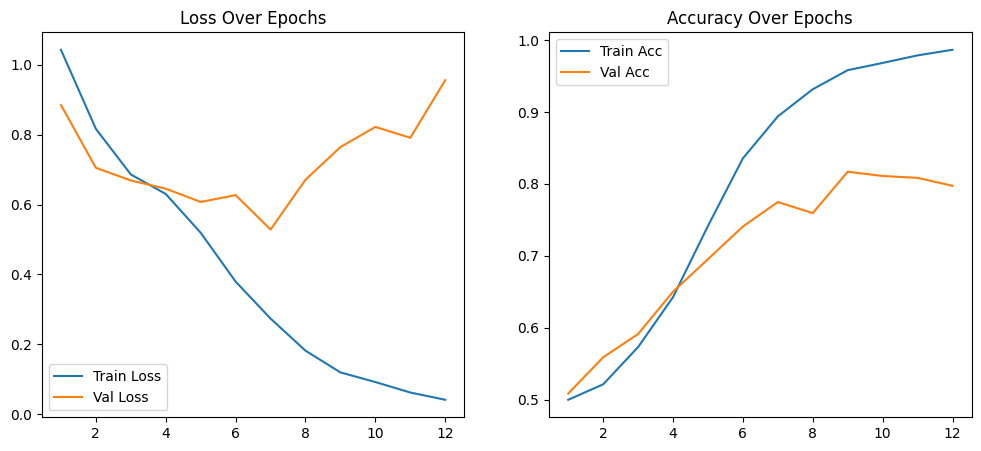

In [10]:
# Config file for the IMDB sentiment analysis project
config_file = "configs/config_gpt2.yaml"
config = IMDBConfig.from_yaml(config_file)

# Create an instance of a TrainerHighLevel with a toy dataset
trainer = TrainerHighLevel(
                           config=config,
                           run_name="config_gpt2",
                           config_file=None, 
                           data_limit=None, # Set to None for full dataset
                           model_class=IMDBModelLPPackedSeq,
                           device='auto',
                           print_every_n_epochs=1,
                           trainer_seed=None  
                           )

# Fit the model using the trainer
trainer.fit()

# Plot the training and validation loss curves
trainer.plot_training_curves()

In [11]:
# Config file for the IMDB sentiment analysis project
config_file = "configs/config_gpt2.yaml"
config = IMDBConfig.from_yaml(config_file)

# Change batch size and patience for early stopping
config.batch_size = 128
config.patience = 3

# Create an instance of a TrainerHighLevel with a toy dataset
trainer = TrainerHighLevel(
                           config=config,
                           run_name="config_gpt2",
                           config_file=None, 
                           data_limit=None, # Set to None for full dataset
                           model_class=IMDBModelLPPackedSeq,
                           device='auto',
                           print_every_n_epochs=1,
                           trainer_seed=None  
                           )

# Fit the model using the trainer
trainer.fit()

🚀 Using hardware accelerator: cuda:0
Epoch   1 | Train Loss: 0.8986 | Train Acc: 0.5036 | Val Loss: 0.7256 | Val Acc: 0.5308
Epoch   2 | Train Loss: 0.6992 | Train Acc: 0.5556 | Val Loss: 0.6688 | Val Acc: 0.5872
Epoch   3 | Train Loss: 0.6287 | Train Acc: 0.6410 | Val Loss: 0.6142 | Val Acc: 0.6598
Epoch   4 | Train Loss: 0.4769 | Train Acc: 0.7740 | Val Loss: 0.5561 | Val Acc: 0.7618
Epoch   5 | Train Loss: 0.3146 | Train Acc: 0.8719 | Val Loss: 0.4541 | Val Acc: 0.8116
Epoch   6 | Train Loss: 0.2313 | Train Acc: 0.9115 | Val Loss: 0.6725 | Val Acc: 0.7794
Epoch   7 | Train Loss: 0.1759 | Train Acc: 0.9364 | Val Loss: 0.3912 | Val Acc: 0.8442
Epoch   8 | Train Loss: 0.1312 | Train Acc: 0.9532 | Val Loss: 0.5849 | Val Acc: 0.8268
Epoch   9 | Train Loss: 0.1002 | Train Acc: 0.9653 | Val Loss: 0.5546 | Val Acc: 0.8318
Epoch  10 | Train Loss: 0.0568 | Train Acc: 0.9808 | Val Loss: 0.5470 | Val Acc: 0.8460

🛑 Early Stopping triggered at epoch 10

✅ Training finished. Loading best model St

## 02 Using BERT tokenizer

In [13]:
# Config file for the IMDB sentiment analysis project
config_file = "configs/config_bert.yaml"
config = IMDBConfig.from_yaml(config_file)

# Create IMDBData instance with the specified configuration
data = IMDBData(config=config, data_limit=None, with_padding=True)

In [14]:
# Config file for the IMDB sentiment analysis project
config_file = "configs/config_bert.yaml"
config = IMDBConfig.from_yaml(config_file)

# Change batch size and patience for early stopping
config.batch_size = 128
config.patience = 3

# Create an instance of a TrainerHighLevel with a toy dataset
trainer = TrainerHighLevel(
                           config=config,
                           run_name="config_bert",
                           config_file=None, 
                           data_limit=None, # Use the full dataset
                           model_class=IMDBModelLPPackedSeq,
                           device='auto',
                           print_every_n_epochs=1,
                           trainer_seed=None
                           )

# Fit the model using the trainer
trainer.fit()

🚀 Using hardware accelerator: cuda:0
Epoch   1 | Train Loss: 0.7993 | Train Acc: 0.5184 | Val Loss: 0.7008 | Val Acc: 0.5372
Epoch   2 | Train Loss: 0.6863 | Train Acc: 0.5598 | Val Loss: 0.6867 | Val Acc: 0.5500
Epoch   3 | Train Loss: 0.6153 | Train Acc: 0.6515 | Val Loss: 0.5941 | Val Acc: 0.6808
Epoch   4 | Train Loss: 0.4458 | Train Acc: 0.7957 | Val Loss: 0.4079 | Val Acc: 0.8186
Epoch   5 | Train Loss: 0.2914 | Train Acc: 0.8839 | Val Loss: 0.4173 | Val Acc: 0.8570
Epoch   6 | Train Loss: 0.2439 | Train Acc: 0.9152 | Val Loss: 0.3898 | Val Acc: 0.8462
Epoch   7 | Train Loss: 0.2010 | Train Acc: 0.9275 | Val Loss: 0.4783 | Val Acc: 0.7930
Epoch   8 | Train Loss: 0.1946 | Train Acc: 0.9335 | Val Loss: 0.4931 | Val Acc: 0.8312
Epoch   9 | Train Loss: 0.1517 | Train Acc: 0.9469 | Val Loss: 0.4933 | Val Acc: 0.8550

🛑 Early Stopping triggered at epoch 9

✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 6):
├─ Train Loss: 0.2439
├─ Train Acc:  0.9152
├─ 

## 03 Using GPT2 tokenizer: 3 runs with different seeds

In [15]:
# Config file for the IMDB sentiment analysis project
config_file = "configs/config_gpt2.yaml"
config = IMDBConfig.from_yaml(config_file)

# Change batch size and patience for early stopping
config.batch_size = 128
config.patience = 3

In [16]:
for seed in [42, 43, 44]:

    # Create an instance of a TrainerHighLevel with a toy dataset
    trainer = TrainerHighLevel(
                            config=config,
                            run_name=f"config_gpt2_{seed}",
                            config_file=None, 
                            data_limit=None, # Set to None for full dataset
                            model_class=IMDBModelLPPackedSeq,
                            device='auto',
                            trainer_seed=seed,
                            print_every_n_epochs=1,
                            )

    # Fit the model using the trainer
    print(f"\n=== Training with seed {seed} ===")
    trainer.fit()

INFO:lightning_fabric.utilities.seed:Seed set to 42



=== Training with seed 42 ===
🚀 Using hardware accelerator: cuda:0
Epoch   1 | Train Loss: 0.8323 | Train Acc: 0.5099 | Val Loss: 0.7048 | Val Acc: 0.5432
Epoch   2 | Train Loss: 0.6927 | Train Acc: 0.5607 | Val Loss: 0.6728 | Val Acc: 0.5852
Epoch   3 | Train Loss: 0.6217 | Train Acc: 0.6473 | Val Loss: 0.5945 | Val Acc: 0.6806
Epoch   4 | Train Loss: 0.4608 | Train Acc: 0.7931 | Val Loss: 0.5668 | Val Acc: 0.7176
Epoch   5 | Train Loss: 0.3615 | Train Acc: 0.8557 | Val Loss: 0.5069 | Val Acc: 0.8006
Epoch   6 | Train Loss: 0.2466 | Train Acc: 0.9064 | Val Loss: 0.4548 | Val Acc: 0.8322
Epoch   7 | Train Loss: 0.1697 | Train Acc: 0.9406 | Val Loss: 0.5950 | Val Acc: 0.8422
Epoch   8 | Train Loss: 0.1442 | Train Acc: 0.9506 | Val Loss: 0.4895 | Val Acc: 0.8394
Epoch   9 | Train Loss: 0.1004 | Train Acc: 0.9679 | Val Loss: 0.5685 | Val Acc: 0.8300

🛑 Early Stopping triggered at epoch 9

✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 6):
├─ Train Loss: 0

INFO:lightning_fabric.utilities.seed:Seed set to 43



=== Training with seed 43 ===
🚀 Using hardware accelerator: cuda:0
Epoch   1 | Train Loss: 0.8661 | Train Acc: 0.5116 | Val Loss: 0.7216 | Val Acc: 0.5366
Epoch   2 | Train Loss: 0.7028 | Train Acc: 0.5501 | Val Loss: 0.6692 | Val Acc: 0.5926
Epoch   3 | Train Loss: 0.6394 | Train Acc: 0.6299 | Val Loss: 0.6238 | Val Acc: 0.6530
Epoch   4 | Train Loss: 0.4937 | Train Acc: 0.7684 | Val Loss: 0.4541 | Val Acc: 0.8084
Epoch   5 | Train Loss: 0.3447 | Train Acc: 0.8637 | Val Loss: 0.6056 | Val Acc: 0.8048
Epoch   6 | Train Loss: 0.2537 | Train Acc: 0.9083 | Val Loss: 0.4755 | Val Acc: 0.7894
Epoch   7 | Train Loss: 0.1719 | Train Acc: 0.9380 | Val Loss: 0.6115 | Val Acc: 0.7876

🛑 Early Stopping triggered at epoch 7

✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 4):
├─ Train Loss: 0.4937
├─ Train Acc:  0.7684
├─ Val Loss:   0.4541
└─ Val Acc:    0.8084


INFO:lightning_fabric.utilities.seed:Seed set to 44



=== Training with seed 44 ===
🚀 Using hardware accelerator: cuda:0
Epoch   1 | Train Loss: 0.8653 | Train Acc: 0.5090 | Val Loss: 0.7120 | Val Acc: 0.5468
Epoch   2 | Train Loss: 0.6962 | Train Acc: 0.5556 | Val Loss: 0.6652 | Val Acc: 0.6082
Epoch   3 | Train Loss: 0.6278 | Train Acc: 0.6439 | Val Loss: 0.6050 | Val Acc: 0.6702
Epoch   4 | Train Loss: 0.4452 | Train Acc: 0.7976 | Val Loss: 0.4342 | Val Acc: 0.7982
Epoch   5 | Train Loss: 0.2749 | Train Acc: 0.8940 | Val Loss: 0.4086 | Val Acc: 0.8160
Epoch   6 | Train Loss: 0.2117 | Train Acc: 0.9248 | Val Loss: 0.4723 | Val Acc: 0.8064
Epoch   7 | Train Loss: 0.1706 | Train Acc: 0.9414 | Val Loss: 0.6216 | Val Acc: 0.8452
Epoch   8 | Train Loss: 0.1247 | Train Acc: 0.9573 | Val Loss: 0.5213 | Val Acc: 0.8458

🛑 Early Stopping triggered at epoch 8

✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 5):
├─ Train Loss: 0.2749
├─ Train Acc:  0.8940
├─ Val Loss:   0.4086
└─ Val Acc:    0.8160


## 04 Using BERT tokenizer: 3 runs with different seeds

In [17]:
# Config file for the IMDB sentiment analysis project
config_file = "configs/config_bert.yaml"
config = IMDBConfig.from_yaml(config_file)

# Change batch size and patience for early stopping
config.batch_size = 128
config.patience = 3

In [18]:
for seed in [42, 43, 44]:

    # Create an instance of a TrainerHighLevel with a toy dataset
    trainer = TrainerHighLevel(
                            config=config,
                            run_name=f"config_bert_{seed}",
                            config_file=None, 
                            data_limit=None, # Use the full dataset
                            model_class=IMDBModelLPPackedSeq,
                            device='auto',
                            print_every_n_epochs=1,
                            trainer_seed=seed
                            )

    # Fit the model using the trainer
    print(f"\n=== Training with seed {seed} ===")
    trainer.fit()

INFO:lightning_fabric.utilities.seed:Seed set to 42



=== Training with seed 42 ===
🚀 Using hardware accelerator: cuda:0
Epoch   1 | Train Loss: 0.8888 | Train Acc: 0.5098 | Val Loss: 0.6970 | Val Acc: 0.5442
Epoch   2 | Train Loss: 0.6885 | Train Acc: 0.5621 | Val Loss: 0.6613 | Val Acc: 0.5992
Epoch   3 | Train Loss: 0.6179 | Train Acc: 0.6557 | Val Loss: 0.5950 | Val Acc: 0.6756
Epoch   4 | Train Loss: 0.4861 | Train Acc: 0.7685 | Val Loss: 0.4672 | Val Acc: 0.8070
Epoch   5 | Train Loss: 0.3406 | Train Acc: 0.8610 | Val Loss: 0.4502 | Val Acc: 0.7970
Epoch   6 | Train Loss: 0.2622 | Train Acc: 0.9002 | Val Loss: 0.4701 | Val Acc: 0.8182
Epoch   7 | Train Loss: 0.1998 | Train Acc: 0.9294 | Val Loss: 0.4644 | Val Acc: 0.7970


INFO:lightning_fabric.utilities.seed:Seed set to 43


Epoch   8 | Train Loss: 0.1874 | Train Acc: 0.9351 | Val Loss: 0.4922 | Val Acc: 0.8012

🛑 Early Stopping triggered at epoch 8

✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 5):
├─ Train Loss: 0.3406
├─ Train Acc:  0.8610
├─ Val Loss:   0.4502
└─ Val Acc:    0.7970

=== Training with seed 43 ===
🚀 Using hardware accelerator: cuda:0
Epoch   1 | Train Loss: 0.8103 | Train Acc: 0.5148 | Val Loss: 0.6896 | Val Acc: 0.5594
Epoch   2 | Train Loss: 0.6908 | Train Acc: 0.5558 | Val Loss: 0.6649 | Val Acc: 0.5978
Epoch   3 | Train Loss: 0.6257 | Train Acc: 0.6413 | Val Loss: 0.5925 | Val Acc: 0.6772
Epoch   4 | Train Loss: 0.4823 | Train Acc: 0.7682 | Val Loss: 0.4221 | Val Acc: 0.8204
Epoch   5 | Train Loss: 0.3298 | Train Acc: 0.8642 | Val Loss: 0.4038 | Val Acc: 0.8190
Epoch   6 | Train Loss: 0.2311 | Train Acc: 0.9147 | Val Loss: 0.3852 | Val Acc: 0.8360
Epoch   7 | Train Loss: 0.1883 | Train Acc: 0.9323 | Val Loss: 0.4901 | Val Acc: 0.8260
Epoch   8 | Trai

INFO:lightning_fabric.utilities.seed:Seed set to 44


Epoch   9 | Train Loss: 0.1317 | Train Acc: 0.9553 | Val Loss: 0.5082 | Val Acc: 0.8568

🛑 Early Stopping triggered at epoch 9

✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 6):
├─ Train Loss: 0.2311
├─ Train Acc:  0.9147
├─ Val Loss:   0.3852
└─ Val Acc:    0.8360

=== Training with seed 44 ===
🚀 Using hardware accelerator: cuda:0
Epoch   1 | Train Loss: 0.8025 | Train Acc: 0.5226 | Val Loss: 0.6903 | Val Acc: 0.5696
Epoch   2 | Train Loss: 0.6807 | Train Acc: 0.5761 | Val Loss: 0.6596 | Val Acc: 0.6048
Epoch   3 | Train Loss: 0.6116 | Train Acc: 0.6625 | Val Loss: 0.5986 | Val Acc: 0.6788
Epoch   4 | Train Loss: 0.4747 | Train Acc: 0.7811 | Val Loss: 0.6280 | Val Acc: 0.7550
Epoch   5 | Train Loss: 0.4033 | Train Acc: 0.8385 | Val Loss: 0.4690 | Val Acc: 0.8222
Epoch   6 | Train Loss: 0.2900 | Train Acc: 0.8953 | Val Loss: 0.5182 | Val Acc: 0.8212
Epoch   7 | Train Loss: 0.2314 | Train Acc: 0.9136 | Val Loss: 0.3721 | Val Acc: 0.8620
Epoch   8 | Trai

## 05 Using BERT tokenizer: No early stopping

In [5]:
# Config file for the IMDB sentiment analysis project
config_file = "configs/config_bert.yaml"
config = IMDBConfig.from_yaml(config_file)

# Change batch size and patience for early stopping
config.epochs = 10
config.patience = 10
config.scheduler_type = "one_cycle"

In [7]:
# Create IMDBData instance with the specified configuration
data = IMDBData(config=config, data_limit=None, with_padding=True)

In [8]:
for seed in [42, 43, 44]:

    # Create an instance of a TrainerHighLevel with a toy dataset
    trainer = TrainerHighLevel(
                            config=config,
                            run_name=f"config_bert_{seed}",
                            config_file=None, 
                            data_limit=None, # Use the full dataset
                            model_class=IMDBModelLPPackedSeq,
                            device='auto',
                            print_every_n_epochs=1,
                            trainer_seed=seed
                            )

    # Fit the model using the trainer
    print(f"\n=== Training with seed {seed} ===")
    trainer.fit()


=== Training with seed 42 ===
🚀 Using hardware accelerator: cuda:0


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (40) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers`

Epoch   1 | Train Loss: 1.0623 | Train Acc: 0.4983 | Val Loss: 0.7208 | Val Acc: 0.5412
Epoch   2 | Train Loss: 0.6962 | Train Acc: 0.5582 | Val Loss: 0.6506 | Val Acc: 0.6116
Epoch   3 | Train Loss: 0.5651 | Train Acc: 0.7075 | Val Loss: 0.5594 | Val Acc: 0.7162
Epoch   4 | Train Loss: 0.3919 | Train Acc: 0.8235 | Val Loss: 0.4741 | Val Acc: 0.7818
Epoch   5 | Train Loss: 0.2891 | Train Acc: 0.8873 | Val Loss: 0.4829 | Val Acc: 0.7908
Epoch   6 | Train Loss: 0.2410 | Train Acc: 0.9114 | Val Loss: 0.4913 | Val Acc: 0.8378
Epoch   7 | Train Loss: 0.1531 | Train Acc: 0.9455 | Val Loss: 0.4741 | Val Acc: 0.8336
Epoch   8 | Train Loss: 0.1054 | Train Acc: 0.9661 | Val Loss: 0.5155 | Val Acc: 0.8422
Epoch   9 | Train Loss: 0.0761 | Train Acc: 0.9776 | Val Loss: 0.5279 | Val Acc: 0.8362
Epoch  10 | Train Loss: 0.0664 | Train Acc: 0.9819 | Val Loss: 0.5331 | Val Acc: 0.8404

✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 4):
├─ Train Loss: 0.3919
├─ Train Acc:

In [9]:
# Change epochs and patience for early stopping
config.epochs = 15
config.patience = 15

In [10]:
for seed in [42, 43, 44]:

    # Create an instance of a TrainerHighLevel with a toy dataset
    trainer = TrainerHighLevel(
                            config=config,
                            run_name=f"config_bert_{seed}",
                            config_file=None, 
                            data_limit=None, # Use the full dataset
                            model_class=IMDBModelLPPackedSeq,
                            device='auto',
                            print_every_n_epochs=1,
                            trainer_seed=seed
                            )

    # Fit the model using the trainer
    print(f"\n=== Training with seed {seed} ===")
    trainer.fit()


=== Training with seed 42 ===
🚀 Using hardware accelerator: cuda:0


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/DL_projects_2026/01-sentiment-analysis/checkpoints/config_bert_42 exists and is not empty.


Epoch   1 | Train Loss: 1.0883 | Train Acc: 0.4974 | Val Loss: 0.7835 | Val Acc: 0.5142
Epoch   2 | Train Loss: 0.7375 | Train Acc: 0.5380 | Val Loss: 0.6816 | Val Acc: 0.5532
Epoch   3 | Train Loss: 0.6442 | Train Acc: 0.6235 | Val Loss: 0.6398 | Val Acc: 0.6368
Epoch   4 | Train Loss: 0.5203 | Train Acc: 0.7397 | Val Loss: 0.5643 | Val Acc: 0.7426
Epoch   5 | Train Loss: 0.3243 | Train Acc: 0.8653 | Val Loss: 0.4605 | Val Acc: 0.7894
Epoch   6 | Train Loss: 0.2289 | Train Acc: 0.9130 | Val Loss: 0.4490 | Val Acc: 0.8258
Epoch   7 | Train Loss: 0.1642 | Train Acc: 0.9426 | Val Loss: 0.5122 | Val Acc: 0.8068
Epoch   8 | Train Loss: 0.1635 | Train Acc: 0.9401 | Val Loss: 0.7707 | Val Acc: 0.7972
Epoch   9 | Train Loss: 0.1220 | Train Acc: 0.9585 | Val Loss: 0.6008 | Val Acc: 0.8446
Epoch  10 | Train Loss: 0.0966 | Train Acc: 0.9658 | Val Loss: 0.6035 | Val Acc: 0.8410
Epoch  11 | Train Loss: 0.0489 | Train Acc: 0.9855 | Val Loss: 0.7038 | Val Acc: 0.8342
Epoch  12 | Train Loss: 0.0335 |

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/DL_projects_2026/01-sentiment-analysis/checkpoints/config_bert_43 exists and is not empty.


Epoch   1 | Train Loss: 0.8852 | Train Acc: 0.5102 | Val Loss: 0.7270 | Val Acc: 0.5366
Epoch   2 | Train Loss: 0.7097 | Train Acc: 0.5422 | Val Loss: 0.6733 | Val Acc: 0.5824
Epoch   3 | Train Loss: 0.6503 | Train Acc: 0.6143 | Val Loss: 0.6365 | Val Acc: 0.6398
Epoch   4 | Train Loss: 0.5454 | Train Acc: 0.7214 | Val Loss: 0.5541 | Val Acc: 0.7096
Epoch   5 | Train Loss: 0.3837 | Train Acc: 0.8316 | Val Loss: 0.4931 | Val Acc: 0.7848
Epoch   6 | Train Loss: 0.3000 | Train Acc: 0.8878 | Val Loss: 0.5031 | Val Acc: 0.7830
Epoch   7 | Train Loss: 0.2049 | Train Acc: 0.9215 | Val Loss: 0.5039 | Val Acc: 0.8242
Epoch   8 | Train Loss: 0.1427 | Train Acc: 0.9491 | Val Loss: 0.5040 | Val Acc: 0.8196
Epoch   9 | Train Loss: 0.1022 | Train Acc: 0.9669 | Val Loss: 0.5882 | Val Acc: 0.8224
Epoch  10 | Train Loss: 0.0724 | Train Acc: 0.9778 | Val Loss: 0.6346 | Val Acc: 0.8268
Epoch  11 | Train Loss: 0.0519 | Train Acc: 0.9852 | Val Loss: 0.7160 | Val Acc: 0.8152
Epoch  12 | Train Loss: 0.0380 |

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/DL_projects_2026/01-sentiment-analysis/checkpoints/config_bert_44 exists and is not empty.


Epoch   1 | Train Loss: 0.8698 | Train Acc: 0.5234 | Val Loss: 0.7179 | Val Acc: 0.5496
Epoch   2 | Train Loss: 0.7036 | Train Acc: 0.5573 | Val Loss: 0.6684 | Val Acc: 0.5998
Epoch   3 | Train Loss: 0.6448 | Train Acc: 0.6266 | Val Loss: 0.6360 | Val Acc: 0.6436
Epoch   4 | Train Loss: 0.5493 | Train Acc: 0.7179 | Val Loss: 0.6300 | Val Acc: 0.6826
Epoch   5 | Train Loss: 0.4242 | Train Acc: 0.8044 | Val Loss: 0.5950 | Val Acc: 0.8172
Epoch   6 | Train Loss: 0.4302 | Train Acc: 0.8374 | Val Loss: 0.6312 | Val Acc: 0.7246
Epoch   7 | Train Loss: 0.3052 | Train Acc: 0.8834 | Val Loss: 0.6085 | Val Acc: 0.7618
Epoch   8 | Train Loss: 0.1924 | Train Acc: 0.9287 | Val Loss: 0.6278 | Val Acc: 0.8076
Epoch   9 | Train Loss: 0.1851 | Train Acc: 0.9341 | Val Loss: 0.5110 | Val Acc: 0.8040
Epoch  10 | Train Loss: 0.1167 | Train Acc: 0.9614 | Val Loss: 0.5236 | Val Acc: 0.8172
Epoch  11 | Train Loss: 0.0767 | Train Acc: 0.9766 | Val Loss: 0.6058 | Val Acc: 0.8250
Epoch  12 | Train Loss: 0.0537 |

## 06 Using BERT tokenizer: `ReduceLROnPlateau`

In [ ]:
# Config file for the IMDB sentiment analysis project
config_file = "configs/config_bert.yaml"
config = IMDBConfig.from_yaml(config_file)

# Print batch size, epochs, patience, and scheduler type
print(f"Batch size: {config.batch_size}")
print(f"Epochs: {config.epochs}")
print(f"Patience: {config.patience}")
print(f"Scheduler type: {config.scheduler_type}")

# Create IMDBData instance with the specified configuration
data = IMDBData(config=config, data_limit=None, with_padding=True)

In [ ]:
for seed in [42, 43, 44]:

    # Create an instance of a TrainerHighLevel with a toy dataset
    trainer = TrainerHighLevel(
                            config=config,
                            run_name=f"config_bert_{seed}",
                            config_file=None, 
                            data_limit=None, # Use the full dataset
                            model_class=IMDBModelLPPackedSeq,
                            device='auto',
                            print_every_n_epochs=1,
                            trainer_seed=seed
                            )

    # Fit the model using the trainer
    print(f"\n=== Training with seed {seed} ===")
    trainer.fit()